In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from tqdm import tqdm

from src.datasets import QM9Dataset
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=5000, stratify_by=['num_atoms', 'gap'], sampling_strategy="stratified")
df = qm9.load()

2026-04-07 18:13:33.128 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-07 18:13:33.380 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-07 18:13:33.381 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-07 18:13:33.381 | INFO     | src.datasets:_add_requested_descriptors:150 - No new descriptor columns added (already present or none requested).


In [4]:
features_1 = ['ea']
features_2 = ['en', 'ion_en']
features_3 = ['en']
features_4 = ['ion_en', 'z', 'en']
features_5 = ['coord', 'ea']
features_6 = ['coord', 'min_neighbor_dist', 'ea', 'ion_en']
relevant_features = ['coord', 'mendeleev', 'ion_en']

raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=relevant_features)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(raw_matrix)


 Cophenetic Correlation Coefficient: 0.7761 (Closer to 1.0 is better)



Evaluating Hierarchical Tree slices: 100%|██████████| 18/18 [00:04<00:00,  4.49it/s]


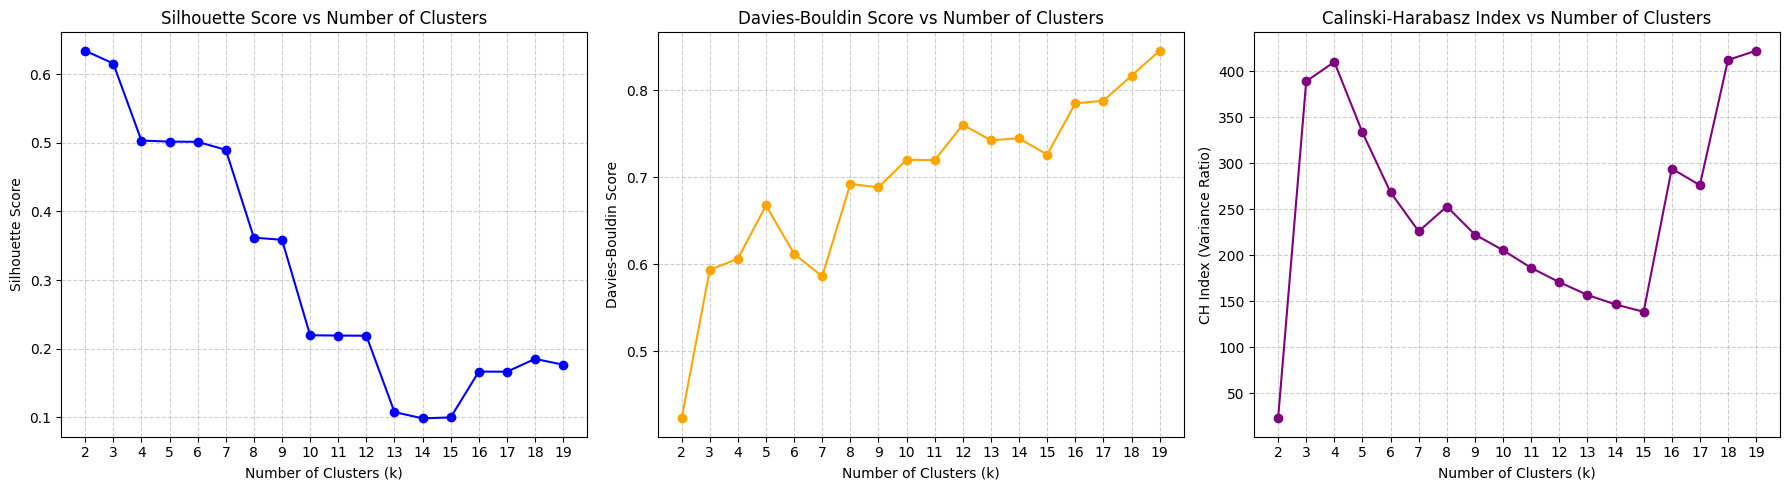

In [5]:
dist_matrix = pdist(scaled_matrix)

Z = linkage(scaled_matrix, method='average') 

# 3. Compute Cophenetic Correlation Coefficient (Evaluates the whole tree)
c, coph_dists = cophenet(Z, dist_matrix)
print(f"\n Cophenetic Correlation Coefficient: {c:.4f} (Closer to 1.0 is better)\n")

# Prepare for the loop
sil_scores = []
db_scores = []
ch_scores = [] 

k_max = 20
k_range = range(2, k_max)

# 4. Evaluate metrics across different cluster counts (k)
for i in tqdm(k_range, desc="Evaluating Hierarchical Tree slices"):
    # fcluster slices the pre-computed tree into 'i' clusters incredibly fast
    labels = fcluster(Z, t=i, criterion='maxclust')
    
    # Calculate Standard Metrics
    sil = silhouette_score(scaled_matrix, labels)
    db = davies_bouldin_score(scaled_matrix, labels)
    ch = calinski_harabasz_score(scaled_matrix, labels) # Replaces Inertia/Gap
    
    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)

# 5. Plotting
plt.figure(figsize=(18, 5))

# Plot 1: Silhouette Score (Higher is better)
plt.subplot(1, 3, 1)
plt.plot(k_range, sil_scores, marker='o', color='blue')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Davies-Bouldin Score (Lower is better)
plt.subplot(1, 3, 2)
plt.plot(k_range, db_scores, marker='o', color='orange')
plt.title('Davies-Bouldin Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Score')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Calinski-Harabasz Index (Higher is better)
plt.subplot(1, 3, 3)
plt.plot(k_range, ch_scores, marker='o', color='purple')
plt.title('Calinski-Harabasz Index vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('CH Index (Variance Ratio)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

best number of clusters --> 6, 7, 15

In [13]:
from scipy.spatial.distance import squareform
k = 16
labels = fcluster(Z, t=k, criterion='maxclust')
df = df.with_columns(pl.Series("cluster_label", labels))
print(f"Cluster distribution for k={k}: {np.unique(labels, return_counts=True)}")

Cluster distribution for k=16: (array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
      dtype=int32), array([   2,    5,   30,   16,    5,   14,    1,    8,   83,   19,  977,
       3781,    1,    2,    2,   54]))


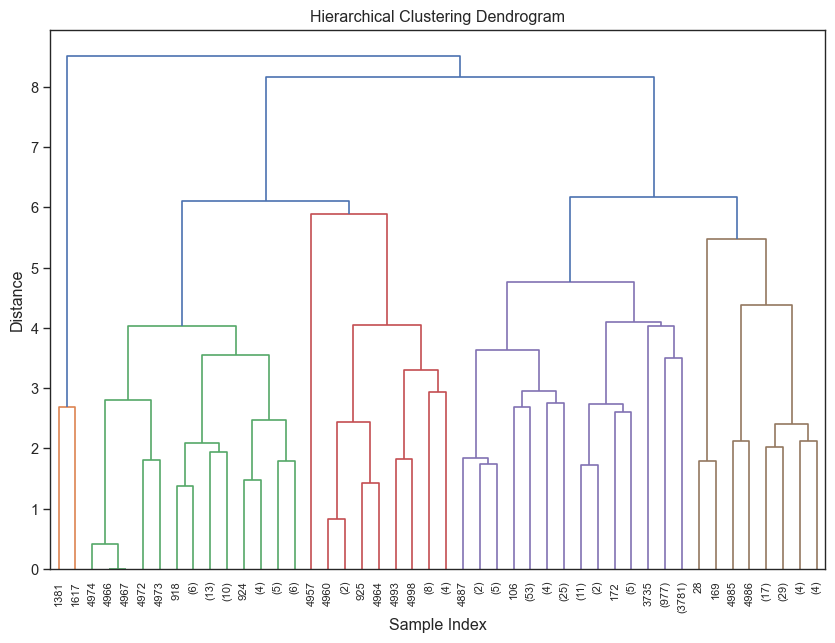

In [14]:
# show dendrogram
from scipy.cluster.hierarchy import dendrogram
plt.figure(figsize=(10, 7))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
dendrogram(Z, truncate_mode='level', p=6)  # Show only the
plt.show()


In [15]:
create_chemiscope_viewer(df,scaled_matrix, labels=labels, reduction_method='t-SNE')

Running t-SNE dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_t-SNE_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - t-SNE Clustering'}, settings={'map': {'x': {'property': 't-SNE_1'}, 'y'…

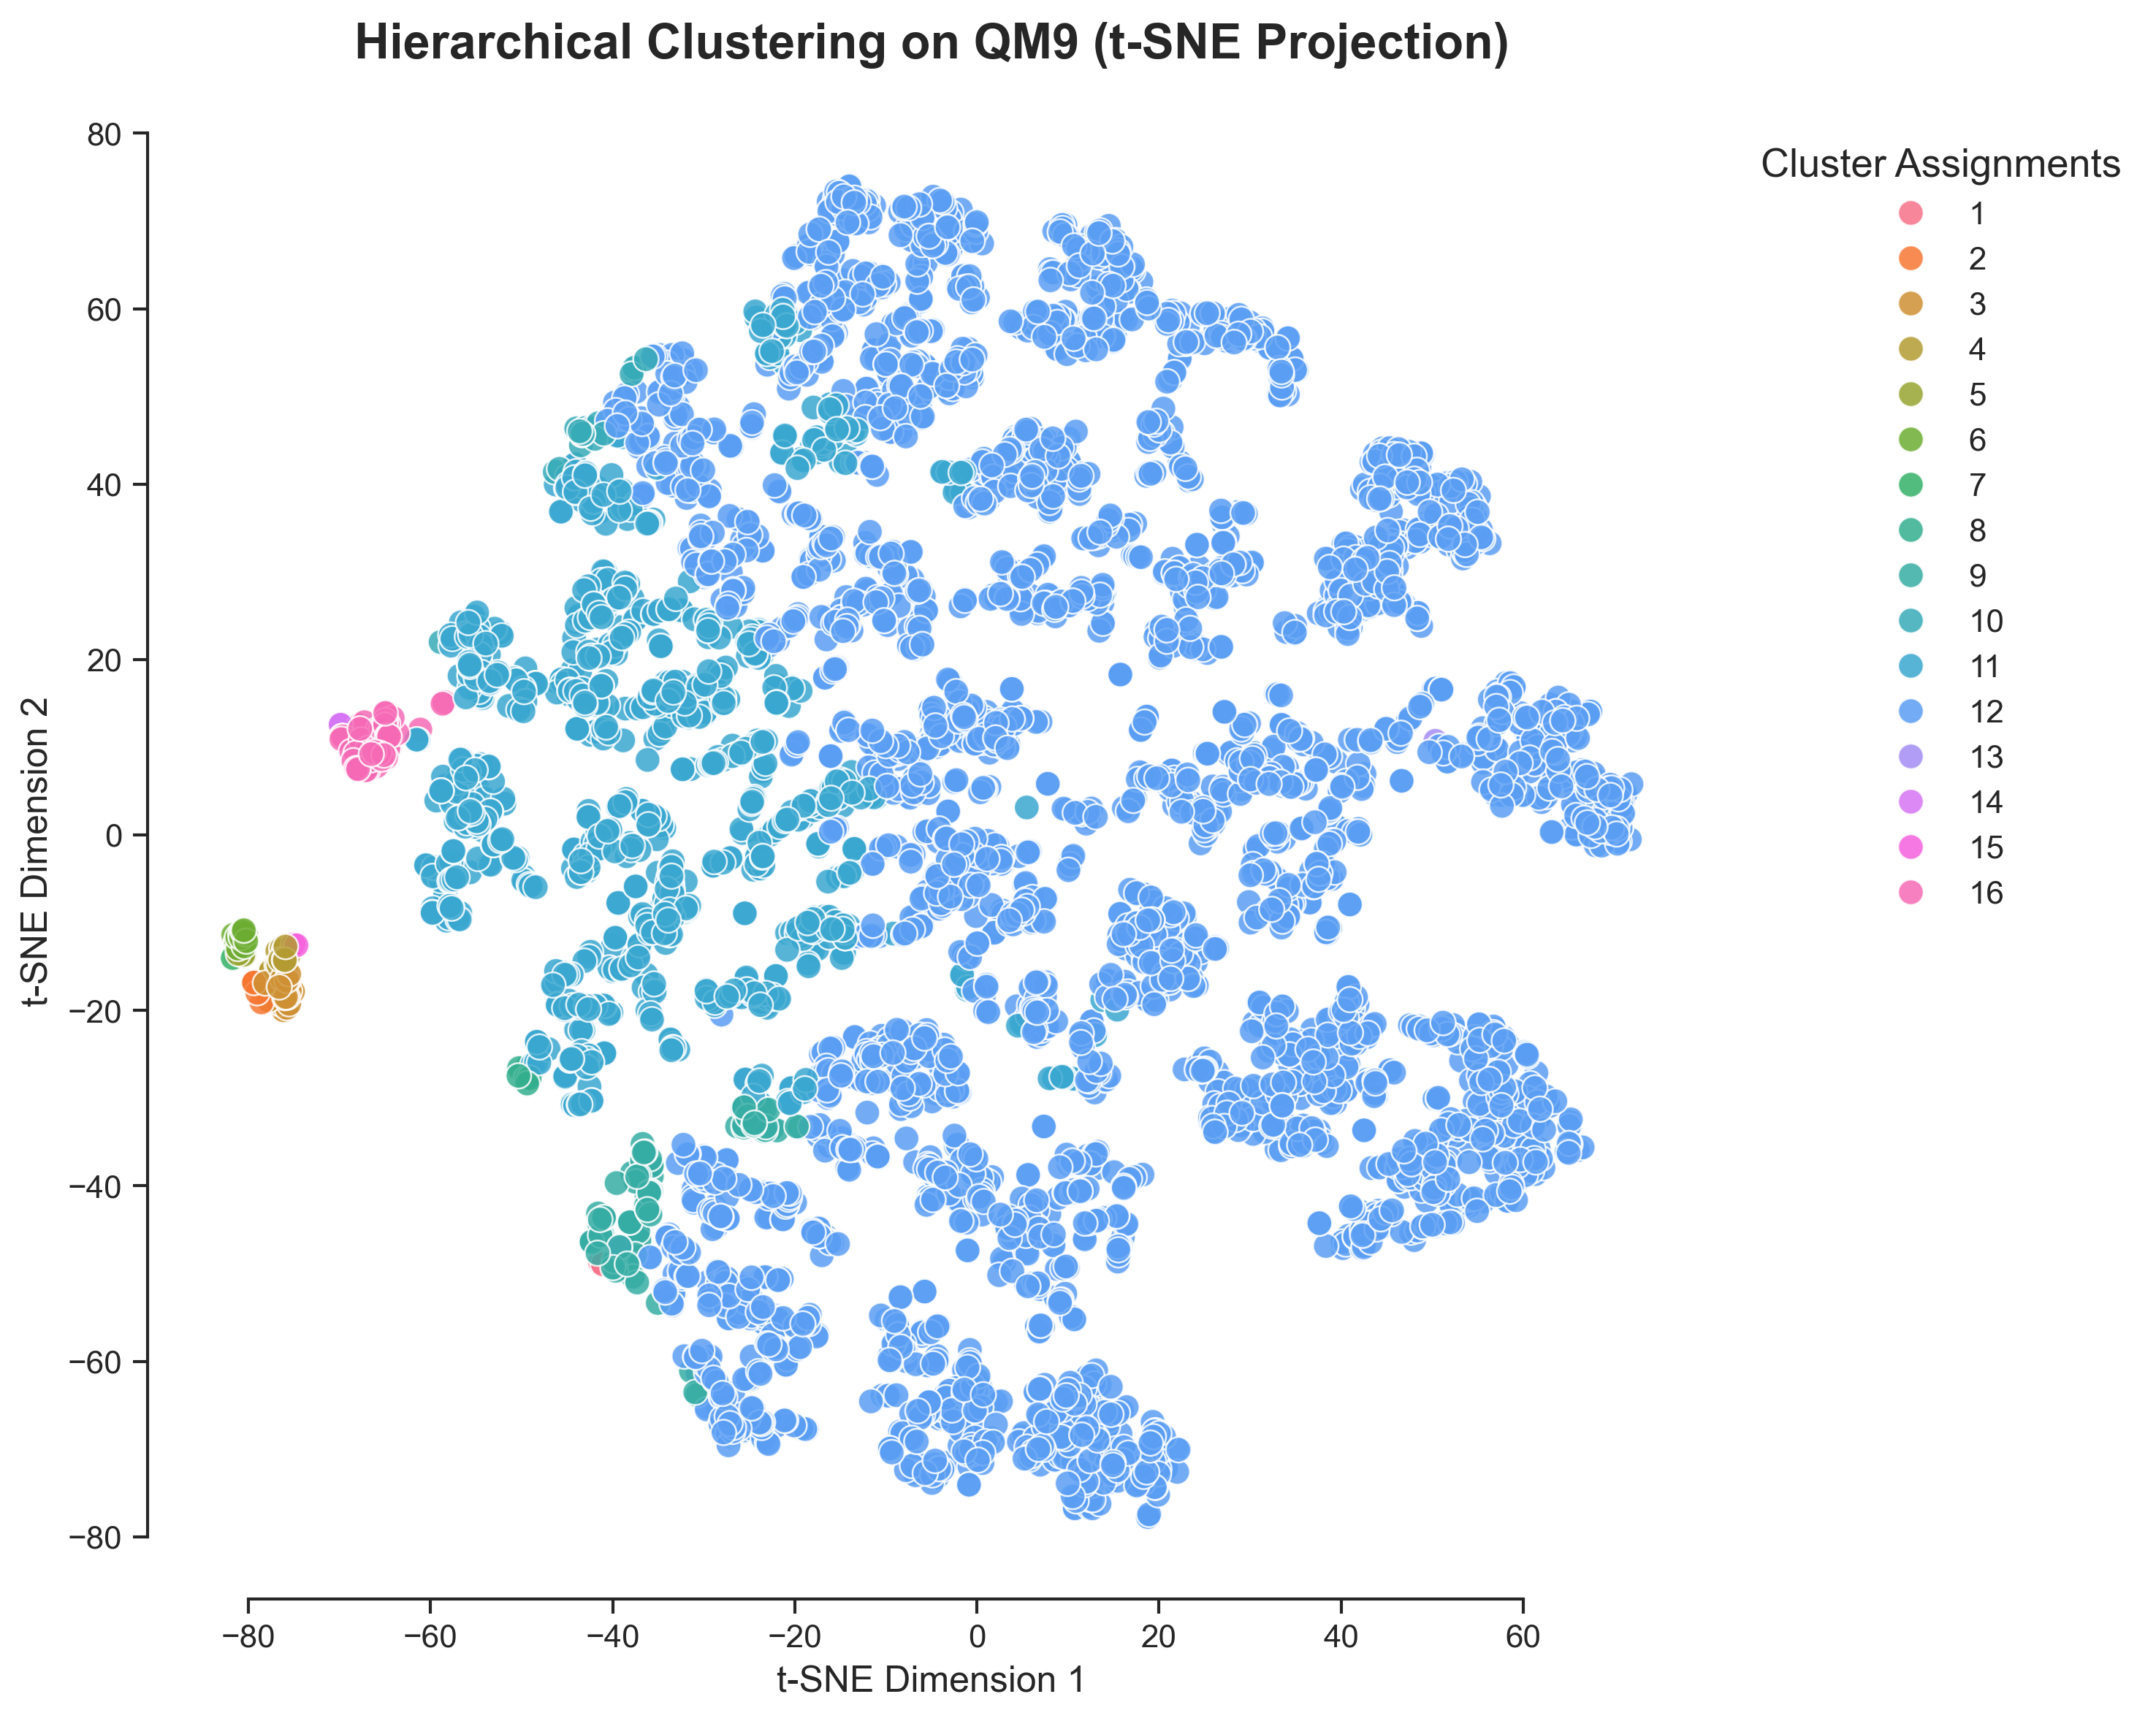

In [17]:
# 1. Setup UMAP (added n_neighbors and min_dist for better aesthetic tuning)
# umap_reducer = UMAP(n_components=2, metric='euclidean', n_neighbors=15, min_dist=0.1, random_state=42)
# umap_embedding = umap_reducer.fit_transform(scaled_matrix)

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
pca_embedding = tsne.fit_transform(scaled_matrix)

# pca reducer
# pca_reducer = PCA(n_components=2, random_state=42)
# pca_embedding = pca_reducer.fit_transform(scaled_matrix)

# 2. Setup Professional Plot Style
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300) # High DPI makes it crisp for papers/presentations

# Convert labels to numpy array for boolean masking
labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

# 3. Plot Noise First (so it stays in the background!)
noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        pca_embedding[noise_mask, 0], 
        pca_embedding[noise_mask, 1], 
        c='#B0B0B0',        # Soft silver/grey
        s=15,               # Smaller size
        alpha=0.4,          # Highly transparent
        label='Noise (-1)',
        edgecolors='none'
    )

# 4. Plot the Valid Clusters
cluster_mask = (labels != -1)
if cluster_mask.any():
    # Use a vibrant, visually pleasing palette
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=pca_embedding[cluster_mask, 0], 
        y=pca_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,               # Larger size for valid points
        alpha=0.85,         # Slight transparency to show density
        edgecolor='white',  # Adds a crisp outline to overlapping points
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

# 5. Typography and Labels
ax.set_title('Hierarchical Clustering on QM9 (t-SNE Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='medium')

# 6. Clean up the box/axes (Despine)
sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

# Save it as a high-quality image (optional)
plt.savefig("figures/qm9/clustering/hierarchical/invariant_features/hier_tsne_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

In [11]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )

cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)


shape: (15, 54)
┌───────────────┬───────────┬────────────┬───────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬─────────────┬─────────────┬─────────────┬────────────┬──────────┬──────────┬──────────┐
│ cluster_label ┆ num_atoms ┆ mol_weight ┆ logp      ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings ┆ num_aromatic_rings ┆ coordination ┆ num_rotatable_bo

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_56716/4183903342.py:9: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()
